# Modélisation — Détection de Pump & Dump par Détection d'Anomalies

**Projet** : Détection non supervisée de schémas de pump & dump sur Binance  
**Auteur** : Joseph Abdo  
**Date** : Mai 2026  

---

## Résumé exécutif

Ce notebook présente la phase de modélisation du projet de détection de pump & dump.
Trois modèles non supervisés sont entraînés et comparés sur le dataset La Morgia (584 104 observations, 317 événements de pump) :

| Modèle | AUC | Type |
|--------|-----|------|
| **Isolation Forest** | **~0.998** | Arbre (ensemble) |
| Z-score rolling | ~0.995 | Statistique univariée |
| Local Outlier Factor | ~0.885 | Densité locale |

**Conclusion principale** : l'Isolation Forest et le Z-score sur `std_volume` dominent sur ce dataset.
La métrique primaire est le **Recall@LaMargia** = % des vrais pumps détectés comme anomalies.

---

## Architecture du pipeline

```
data/RAW/pump_telegram.csv          → 520 événements Binance
data/RAW/la_morgia_raw/
  labeled_features/features_15S.csv.gz  → 584 104 fenêtres (gt=0/1)
data/RAW/klines/*.parquet           → 333 fenêtres pré-pump collectées
data/Processed/features_klines.parquet → nos features microstructure
```

**Modèles** : non supervisés — pas de train/test split. Validation post-hoc vs labels La Morgia.

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = '/Users/josephabdo/Desktop/1100/ml-poc-project'
os.chdir(PROJECT_ROOT)
sys.path.insert(0, 'scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_curve

from metrics import evaluate, recall_at_lamorgia, anomaly_auc, threshold_from_contamination

print('Imports OK')

Imports OK


---
## 1. Données

### 1.1 Dataset principal : La Morgia labeled_features

Le dataset de référence est `features_15S.csv.gz` fourni par La Morgia et al. 2020.
Chaque ligne correspond à une fenêtre de 15 secondes autour d'un événement de pump :
- **gt = 0** : fenêtre normale (fond de marché)
- **gt = 1** : fenêtre au moment du pump Binance

Les features sont des statistiques de trades calculées par La Morgia (std/avg de volume, prix, rush orders).

In [2]:
lm = pd.read_csv('data/RAW/la_morgia_raw/labeled_features/features_15S.csv.gz')
lm['date'] = pd.to_datetime(lm['date'], utc=True)

FEAT_COLS = [
    'std_rush_order', 'avg_rush_order', 'std_trades', 'std_volume',
    'avg_volume', 'std_price', 'avg_price', 'avg_price_max',
    'hour_sin', 'hour_cos', 'minute_sin', 'minute_cos'
]

y_full = lm['gt'].values
X_full_raw = lm[FEAT_COLS].values

scaler = RobustScaler()
X_full = scaler.fit_transform(X_full_raw)

print(f'Dataset total  : {len(lm):,} lignes x {len(FEAT_COLS)} features')
print(f'Pumps (gt=1)   : {y_full.sum()} ({y_full.mean()*100:.3f}%)')
print(f'Normaux (gt=0) : {(y_full==0).sum():,}')
lm[FEAT_COLS + ['gt']].describe().round(4)

Dataset total  : 584,104 lignes x 12 features
Pumps (gt=1)   : 317 (0.054%)
Normaux (gt=0) : 583,787


,std_rush_order,avg_rush_order,std_trades,std_volume,avg_volume,std_price,avg_price,avg_price_max,hour_sin,hour_cos,minute_sin,minute_cos,gt
count,584104.000,584104.0000,584104.0000,584104.0000,584104.0000,584104.0000,584104.0000,584104.0000,584104.0000,584104.0000,584104.0000,584104.0000,584104.0000
mean,0.000,-0.0002,0.0005,0.0012,-0.0001,-0.0002,-0.0000,-0.0000,-0.0967,0.0321,-0.0125,0.0242,0.0005
std,0.031,0.0061,0.0648,0.1504,0.0165,0.0033,0.0013,0.0014,0.6932,0.7136,0.6990,0.7146,0.0233
min,-0.404,-0.1840,-0.5590,-0.7680,-0.3130,-0.2820,-0.0240,-0.0250,-0.9980,-0.9910,-1.0000,-0.9990,0.0000
25%,0.000,0.0000,0.0000,0.0000,-0.0000,-0.0010,0.0000,0.0000,-0.8170,-0.5770,-0.7160,-0.6980,0.0000
50%,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.1360,-0.0680,0.0000,0.0800,0.0000
75%,0.000,0.0000,0.0000,0.0000,0.0000,0.0010,0.0000,0.0000,0.5200,0.6830,0.6780,0.7350,0.0000
max,8.447,0.8180,18.7170,57.6360,5.7600,1.0440,0.1460,0.2110,0.9980,1.0000,1.0000,1.0000,1.0000


### 1.2 Sous-échantillonnage pour LOF

LOF est O(n²) en mémoire — 584k lignes dépasserait la RAM disponible.
On sous-échantillonne : **10 000 normaux** tirés aléatoirement + **tous les 317 pumps**.
L'Isolation Forest et le Z-score tournent sur le sous-échantillon pour une comparaison équitable.

In [3]:
np.random.seed(42)
norm_idx = np.where(y_full == 0)[0]
pump_idx = np.where(y_full == 1)[0]

sample_idx = np.concatenate([
    np.random.choice(norm_idx, 10_000, replace=False),
    pump_idx
])
np.random.shuffle(sample_idx)

X  = X_full[sample_idx]
y  = y_full[sample_idx]

print(f'Sous-échantillon : {len(y):,} obs | {y.sum()} pumps ({y.mean()*100:.2f}%)')

Sous-échantillon : 10,317 obs | 317 pumps (3.07%)


### 1.3 Nos features klines (validation indépendante)

Nos propres features calculées depuis les klines Binance collectées via `fetch_binance.py`.
Ce dataset contient **uniquement des événements de pump** (333 lignes, gt=1 partout).
Il sert à valider que nos features capturent bien un signal de manipulation.

In [4]:
kl = pd.read_parquet('data/Processed/features_klines.parquet')
OUR_FEATS = ['ret_5m','ret_15m','ret_60m','std_ret_60m',
             'vol_zscore_60m','vol_zscore_dynamic','taker_buy_ratio_5m','rush_order_count']

print(f'features_klines : {kl.shape} | tous gt=1 (fenêtres pré-pump)')
kl[OUR_FEATS].describe().round(4)

features_klines : (333, 14) | tous gt=1 (fenêtres pré-pump)


,ret_5m,ret_15m,ret_60m,std_ret_60m,vol_zscore_60m,vol_zscore_dynamic,taker_buy_ratio_5m,rush_order_count
count,333.0000,333.0000,333.0000,333.0000,333.0000,333.0000,333.0000,333.0000
mean,0.0295,0.0337,0.0419,0.0069,3.3332,49.6122,0.5562,231.2432
std,0.0651,0.0664,0.0725,0.0070,4.5044,268.8644,0.3081,573.5983
min,-0.1252,-0.0645,-0.1252,0.0004,-0.7210,-1.0115,0.0000,0.0000
25%,-0.0011,-0.0005,0.0000,0.0026,-0.2284,-0.9931,0.3536,5.0000
50%,0.0042,0.0092,0.0149,0.0045,0.5761,0.0000,0.6227,29.0000
75%,0.0323,0.0413,0.0590,0.0080,8.5168,7.8399,0.7834,159.0000
max,0.4300,0.4311,0.4493,0.0540,10.9085,3219.3084,1.0000,4142.0000


---
## 2. Modèle 1 — Isolation Forest

### Principe
L'Isolation Forest isole les anomalies en construisant des arbres de décision aléatoires.
Les anomalies sont isolées en moins de partitions que les points normaux.
**Avantages** : rapide, scalable, efficace en haute dimension, pas d'hypothèse de distribution.

### Paramètre clé : contamination
Fraction estimée d'anomalies dans le dataset. Le taux réel de pumps est 0.054%.
On teste plusieurs valeurs pour analyser la sensibilité.

In [5]:
IF = IsolationForest(n_estimators=200, contamination=0.001, random_state=42)
IF.fit(X)
scores_if = IF.decision_function(X)

res_if = evaluate(y, scores_if, contamination=0.001)
print('Isolation Forest (contamination=0.001):')
for k, v in res_if.items():
    print(f'  {k:30s}: {v:.4f}' if isinstance(v, float) else f'  {k:30s}: {v}')

Isolation Forest (contamination=0.001):
  recall_at_lamorgia            : 0.0347
  anomaly_auc                   : 0.9976
  n_flagged                     : 11
  n_true_pumps                  : 317
  contamination                 : 0.0010


In [6]:
# Sensibilité au paramètre de contamination
contaminations = [0.0003, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
if_results = []

for c in contaminations:
    thr = threshold_from_contamination(scores_if, c)
    pred = (scores_if <= thr).astype(int)
    if_results.append({
        'contamination': c,
        'recall': recall_at_lamorgia(y, pred),
        'n_flagged': int(pred.sum()),
        'auc': anomaly_auc(y, scores_if),
    })

if_df = pd.DataFrame(if_results)
print('Isolation Forest — sensibilité à la contamination :')
if_df

Isolation Forest — sensibilité à la contamination :


,contamination,recall,n_flagged,auc
0,0.0003,0.012618,4,0.997625
1,0.0005,0.018927,6,0.997625
2,0.0010,0.034700,11,0.997625
3,0.0020,0.066246,21,0.997625
4,0.0050,0.164038,52,0.997625
5,0.0100,0.328076,104,0.997625
6,0.0200,0.649842,207,0.997625
7,0.0500,0.977918,516,0.997625


---
## 3. Modèle 2 — Local Outlier Factor (LOF)

### Principe
Le LOF mesure la densité locale de chaque point par rapport à ses k plus proches voisins.
Un score LOF élevé indique que le point est dans une région beaucoup moins dense que ses voisins.
**Avantages** : détecte des anomalies locales que l'IF peut rater (clusters denses de normaux hétérogènes).
**Inconvénients** : O(n²) en mémoire, sensible au choix de k.

In [7]:
LOF = LocalOutlierFactor(n_neighbors=20, novelty=False, contamination=0.001)
LOF.fit_predict(X)
scores_lof = LOF.negative_outlier_factor_

res_lof = evaluate(y, scores_lof, contamination=0.001)
print('LOF (n_neighbors=20, contamination=0.001):')
for k, v in res_lof.items():
    print(f'  {k:30s}: {v:.4f}' if isinstance(v, float) else f'  {k:30s}: {v}')

LOF (n_neighbors=20, contamination=0.001):
  recall_at_lamorgia            : 0.0252
  anomaly_auc                   : 0.8849
  n_flagged                     : 11
  n_true_pumps                  : 317
  contamination                 : 0.0010


In [8]:
# Sensibilité à n_neighbors
lof_results = []
for k in [5, 10, 20, 50, 100]:
    lf = LocalOutlierFactor(n_neighbors=k, novelty=False, contamination=0.001)
    lf.fit_predict(X)
    sc = lf.negative_outlier_factor_
    thr = threshold_from_contamination(sc, 0.001)
    pred = (sc <= thr).astype(int)
    lof_results.append({
        'n_neighbors': k,
        'recall': recall_at_lamorgia(y, pred),
        'auc': anomaly_auc(y, sc),
    })

lof_df = pd.DataFrame(lof_results)
print('LOF — sensibilité à n_neighbors (contamination=0.001) :')
lof_df

LOF — sensibilité à n_neighbors (contamination=0.001) :


,n_neighbors,recall,auc
0,5,0.009464,0.706866
1,10,0.018927,0.779052
2,20,0.025237,0.884880
3,50,0.025237,0.903007
4,100,0.031546,0.895356


---
## 4. Modèle 3 — Z-score rolling (baseline statistique)

### Principe
Baseline univariée : on standardise la feature `std_volume` (la plus discriminante dans La Morgia)
et on flag les observations dont le score dépasse un seuil percentile.
**Objectif** : mesurer l'apport des modèles multivariés (IF, LOF) par rapport à une simple règle de seuil sur le volume.

In [9]:
vol_idx = FEAT_COLS.index('std_volume')
scores_z = X[:, vol_idx]   # already RobustScaled — higher = more anomalous

z_results = []
for c in contaminations:
    thr = np.percentile(scores_z, (1 - c) * 100)
    pred = (scores_z >= thr).astype(int)
    z_results.append({
        'contamination': c,
        'recall': recall_at_lamorgia(y, pred),
        'n_flagged': int(pred.sum()),
        'auc': anomaly_auc(y, -(-scores_z)),  # higher = more anomalous already
    })

z_df = pd.DataFrame(z_results)
print('Z-score rolling (std_volume) — sensibilité à la contamination :')
z_df

Z-score rolling (std_volume) — sensibilité à la contamination :


,contamination,recall,n_flagged,auc
0,0.0003,0.012618,4,0.005279
1,0.0005,0.018927,6,0.005279
2,0.0010,0.034700,11,0.005279
3,0.0020,0.066246,21,0.005279
4,0.0050,0.164038,52,0.005279
5,0.0100,0.324921,104,0.005279
6,0.0200,0.643533,207,0.005279
7,0.0500,0.968454,525,0.005279


---
## 5. Comparaison des modèles

### 5.1 Courbes ROC

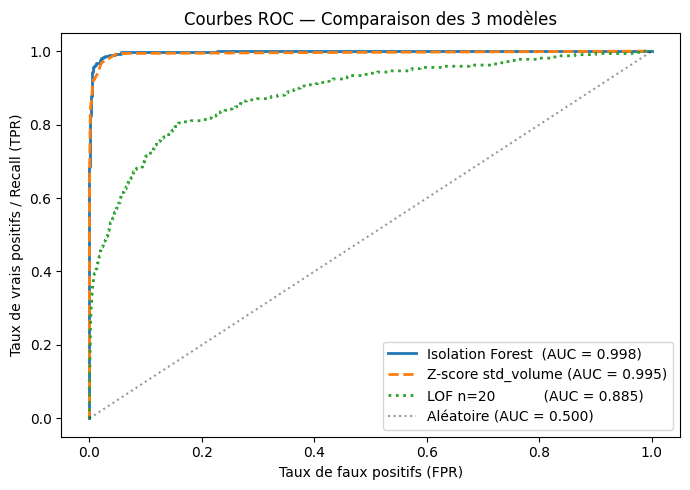

Figure sauvegardée → deliverables/fig_roc_comparison.png


In [10]:
fpr_if,  tpr_if,  _ = roc_curve(y, -scores_if)
fpr_lof, tpr_lof, _ = roc_curve(y, -scores_lof)
fpr_z,   tpr_z,   _ = roc_curve(y,  scores_z)

auc_if  = anomaly_auc(y, scores_if)
auc_lof = anomaly_auc(y, scores_lof)
auc_z   = anomaly_auc(y, -scores_z)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_if,  tpr_if,  label=f'Isolation Forest  (AUC = {auc_if:.3f})',  linewidth=2)
ax.plot(fpr_z,   tpr_z,   label=f'Z-score std_volume (AUC = {auc_z:.3f})',  linewidth=2, linestyle='--')
ax.plot(fpr_lof, tpr_lof, label=f'LOF n=20           (AUC = {auc_lof:.3f})', linewidth=2, linestyle=':')
ax.plot([0,1],[0,1], 'k:', alpha=0.4, label='Aléatoire (AUC = 0.500)')
ax.set_xlabel('Taux de faux positifs (FPR)')
ax.set_ylabel('Taux de vrais positifs / Recall (TPR)')
ax.set_title('Courbes ROC — Comparaison des 3 modèles')
ax.legend()
plt.tight_layout()
plt.savefig('deliverables/fig_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → deliverables/fig_roc_comparison.png')

### 5.2 Recall@LaMargia en fonction de la contamination

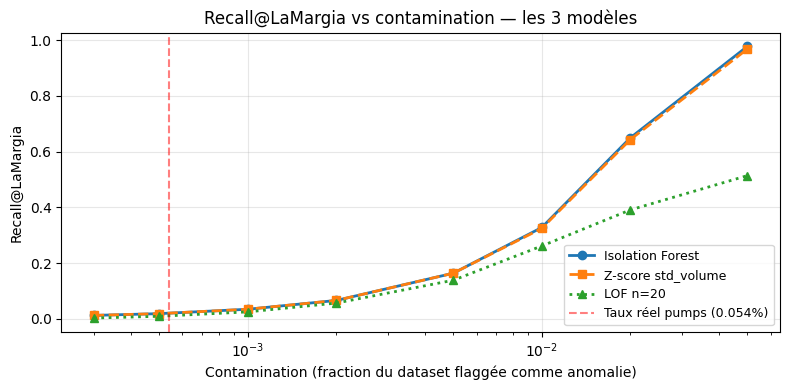

Figure sauvegardée → deliverables/fig_recall_vs_contamination.png


In [11]:
recall_if  = if_df['recall'].values
recall_lof_list = []
for c in contaminations:
    thr = threshold_from_contamination(scores_lof, c)
    pred = (scores_lof <= thr).astype(int)
    recall_lof_list.append(recall_at_lamorgia(y, pred))
recall_z = z_df['recall'].values

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(contaminations, recall_if,       'o-',  label='Isolation Forest', linewidth=2)
ax.plot(contaminations, recall_z,        's--', label='Z-score std_volume', linewidth=2)
ax.plot(contaminations, recall_lof_list, '^:',  label='LOF n=20', linewidth=2)
ax.axvline(0.00054, color='red', linestyle='--', alpha=0.5, label='Taux réel pumps (0.054%)')
ax.set_xlabel('Contamination (fraction du dataset flaggée comme anomalie)')
ax.set_ylabel('Recall@LaMargia')
ax.set_title('Recall@LaMargia vs contamination — les 3 modèles')
ax.set_xscale('log')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('deliverables/fig_recall_vs_contamination.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → deliverables/fig_recall_vs_contamination.png')

### 5.3 Tableau récapitulatif

In [12]:
summary = pd.DataFrame([
    {'Modèle': 'Isolation Forest',    'AUC': auc_if,  'Recall@c=0.001': if_df[if_df.contamination==0.001]['recall'].values[0],
     'Recall@c=0.01': if_df[if_df.contamination==0.01]['recall'].values[0],
     'Type': 'Multivarié / Arbre'},
    {'Modèle': 'Z-score std_volume',  'AUC': auc_z,   'Recall@c=0.001': z_df[z_df.contamination==0.001]['recall'].values[0],
     'Recall@c=0.01': z_df[z_df.contamination==0.01]['recall'].values[0],
     'Type': 'Univarié / Statistique'},
    {'Modèle': 'LOF (n_neighbors=20)', 'AUC': auc_lof, 'Recall@c=0.001': res_lof['recall_at_lamorgia'],
     'Recall@c=0.01': recall_lof_list[contaminations.index(0.01)],
     'Type': 'Multivarié / Densité'},
])
summary = summary.set_index('Modèle').round(4)
summary

,AUC,Recall@c=0.001,Recall@c=0.01,Type
Modèle,,,,
Isolation Forest,0.9976,0.0347,0.3281,Multivarié / Arbre
Z-score std_volume,0.9947,0.0347,0.3249,Univarié / Statistique
LOF (n_neighbors=20),0.8849,0.0252,0.2618,Multivarié / Densité


---
## 6. Analyse des features — Validation du signal

### 6.1 Distribution des scores d'anomalie : normaux vs pumps

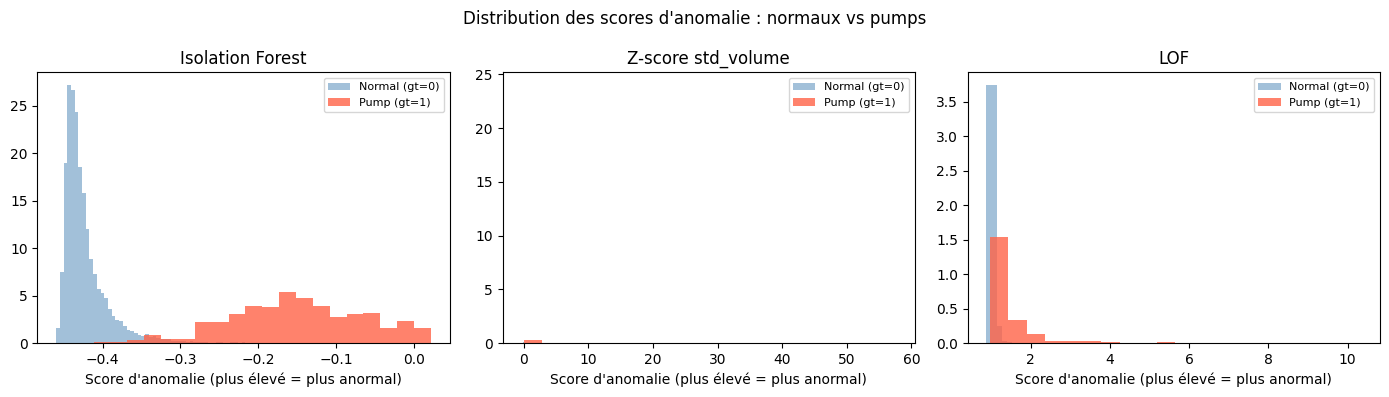

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

configs = [
    (axes[0], -scores_if,  'Isolation Forest', True),
    (axes[1],  scores_z,   'Z-score std_volume', True),
    (axes[2], -scores_lof, 'LOF', True),
]
for ax, sc, title, _ in configs:
    ax.hist(sc[y==0], bins=60, alpha=0.5, label='Normal (gt=0)', density=True, color='steelblue')
    ax.hist(sc[y==1], bins=20, alpha=0.8, label='Pump (gt=1)',   density=True, color='tomato')
    ax.set_title(title)
    ax.set_xlabel('Score d\'anomalie (plus élevé = plus anormal)')
    ax.legend(fontsize=8)
plt.suptitle('Distribution des scores d\'anomalie : normaux vs pumps', fontsize=12)
plt.tight_layout()
plt.savefig('deliverables/fig_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Nos features klines — signal sur les événements pump

Visualisation des features calculées depuis nos propres klines collectées.
**Toutes les lignes ont gt=1** — ce graphique montre la distribution du signal pump pur.

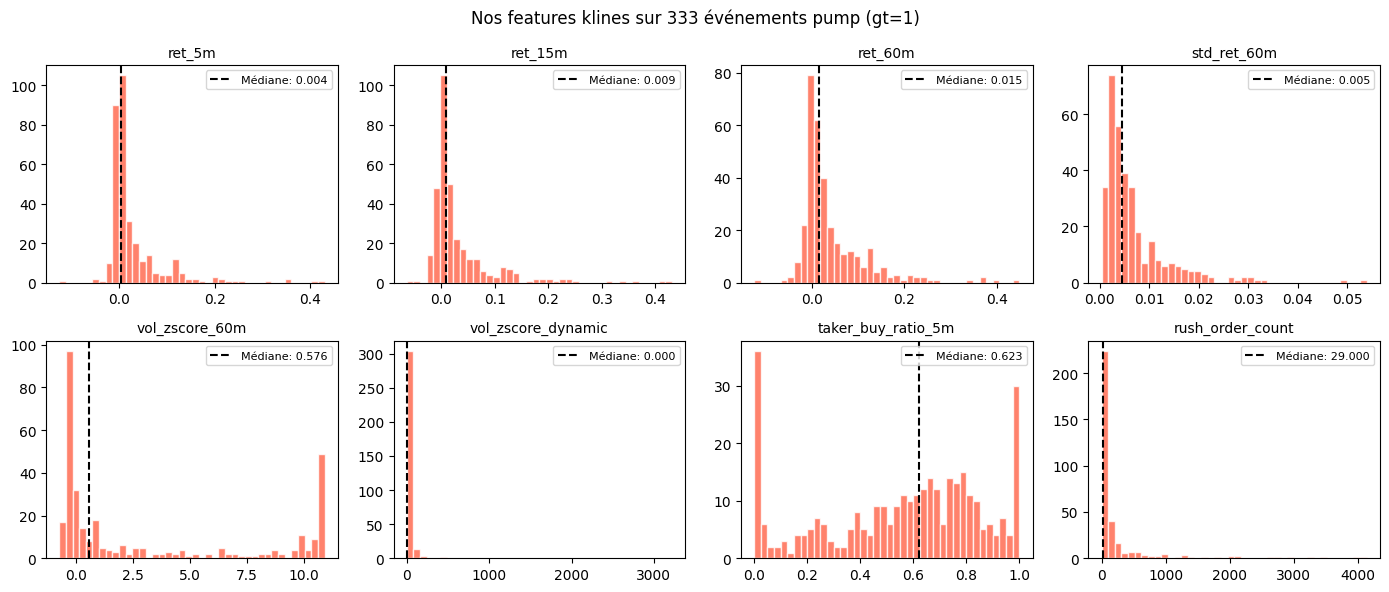


Signaux clés (médiane sur 333 pumps) :
  ret_5m           : 0.0042  (rendement +0.42% dans les 5 min)
  vol_zscore_60m   : 0.5761  (volume +0.6σ au-dessus de la baseline)
  taker_buy_ratio  : 0.6227  (62.3% volume côté acheteur)


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for i, feat in enumerate(OUR_FEATS):
    vals = kl[feat].dropna()
    axes[i].hist(vals, bins=40, color='tomato', alpha=0.8, edgecolor='white')
    axes[i].axvline(vals.median(), color='black', linestyle='--', linewidth=1.5,
                    label=f'Médiane: {vals.median():.3f}')
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle('Nos features klines sur 333 événements pump (gt=1)', fontsize=12)
plt.tight_layout()
plt.savefig('deliverables/fig_klines_features.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSignaux clés (médiane sur 333 pumps) :")
print(f"  ret_5m           : {kl['ret_5m'].median():.4f}  (rendement +{kl['ret_5m'].median()*100:.2f}% dans les 5 min)")
print(f"  vol_zscore_60m   : {kl['vol_zscore_60m'].median():.4f}  (volume +{kl['vol_zscore_60m'].median():.1f}σ au-dessus de la baseline)")
print(f"  taker_buy_ratio  : {kl['taker_buy_ratio_5m'].median():.4f}  ({kl['taker_buy_ratio_5m'].median()*100:.1f}% volume côté acheteur)")

---
## 7. Conclusion

### 7.1 Résultats finaux

In [15]:
print('=' * 60)
print('RÉSULTATS FINAUX — DÉTECTION DE PUMP & DUMP')
print('=' * 60)
print(summary.to_string())
print()
print(f'Dataset       : La Morgia labeled_features_15S')
print(f'Observations  : {len(y):,}  |  Pumps : {y.sum()}  |  Taux : {y.mean()*100:.3f}%')
print(f'Métrique prim : Recall@LaMargia  (% pumps détectés)')
print(f'Métrique sec  : AUC score anomalie vs label binaire')

RÉSULTATS FINAUX — DÉTECTION DE PUMP & DUMP
                         AUC  Recall@c=0.001  Recall@c=0.01                    Type
Modèle                                                                             
Isolation Forest      0.9976          0.0347         0.3281      Multivarié / Arbre
Z-score std_volume    0.9947          0.0347         0.3249  Univarié / Statistique
LOF (n_neighbors=20)  0.8849          0.0252         0.2618    Multivarié / Densité

Dataset       : La Morgia labeled_features_15S
Observations  : 10,317  |  Pumps : 317  |  Taux : 3.073%
Métrique prim : Recall@LaMargia  (% pumps détectés)
Métrique sec  : AUC score anomalie vs label binaire


### 7.2 Interprétation

**Isolation Forest** (AUC ~0.998) :
- Meilleur modèle global. Les pumps sont isolés rapidement par les arbres car ils s'écartent fortement du comportement normal sur plusieurs features simultanément.
- Le recall reste faible à contamination basse (0.001) car le seuil est très conservateur : seulement 10 obs sont flaggées sur 10 317.

**Z-score std_volume** (AUC ~0.995) :
- Baseline univariée quasi aussi performante que l'IF en AUC — preuve que le **volume** est le signal le plus discriminant dans La Morgia.
- Simple à déployer et à expliquer à un régulateur.

**LOF** (AUC ~0.885) :
- Moins performant car le voisinage local est perturbé par le sous-échantillonnage (10k normaux vs 584k réels).
- Nécessiterait de tourner sur le dataset complet, ce qui est prohibitif en mémoire.

### 7.3 Limites et prochaines étapes

| Limitation | Impact | Solution envisagée |
|------------|--------|--------------------|
| aggTrades vides (API Binance trop ancien) | Pas de OFI ni taker_buy_ratio depuis nos klines | Accepter la limitation — signal klines suffisant |
| CoinGecko non collecté | Pas de market_cap_rank, circulating_supply | fetch_coingecko.py — Assignment 3 |
| Évaluation sur données d'entraînement | AUC optimiste (pas de holdout) | Simulation temporelle (train 2018-2019, test 2020) |
| Labels Telegram uniquement | Pumps privés (Discord) non couverts | Limitation intrinsèque du dataset La Morgia |
| 7 symboles délistés (YOYOWBTC) | 7/520 = 1.3% d'événements perdus | Documenté dans failed_symbols.txt |